# EEG Psychiatric Disorders — Classification Hiérarchique
**Input** : `dataset.parquet` (output MS1 Scala)  
**Output** : `results.parquet` (input MS2 Scala)  

**Pipeline en 2 étapes :**
- **Modèle 1** — SVM : détecte si le patient est malade ou sain
- **Modèle 2** — XGBoost : identifie le type de trouble (sur les malades uniquement)

## 1. Imports

In [1]:
import sys
!{sys.executable} -m pip install xgboost --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)
from xgboost import XGBClassifier
import joblib

print('Librairies chargées ')

Librairies chargées 


## 2. Chargement du Parquet (output MS1)

In [2]:
df = pd.read_parquet("C:/Users/nadia/.git/troubles-psy/output/dataset.parquet")
print(f'Shape : {df.shape}')
print(f'Colonnes : {list(df.columns)}')
display(df.head(3))

Shape : (945, 9)
Colonnes : ['id', 'sex', 'age', 'education', 'iq', 'main_disorder', 'specific_disorder', 'ab_features', 'coh_features']


,id,sex,age,education,iq,main_disorder,specific_disorder,ab_features,coh_features
0,1,0,0.723831,0.65,0.552083,Addictive disorder,Alcohol use disorder,"[(AB.C.alpha.o.Pz, 0.07875038430351236), (AB.C...","[(COH.F.gamma.a.FP1.c.F7, 0.46005406042319097)..."
1,2,0,0.352635,0.30,0.739583,Addictive disorder,Alcohol use disorder,"[(AB.C.alpha.o.Pz, 0.18485017569929604), (AB.C...","[(COH.F.gamma.a.FP1.c.F7, 0.410030104537656), ..."
2,3,0,0.259837,0.80,0.666667,Addictive disorder,Alcohol use disorder,"[(AB.C.alpha.o.Pz, 0.07487492337001554), (AB.C...","[(COH.F.gamma.a.FP1.c.F7, 0.847366435557007), ..."


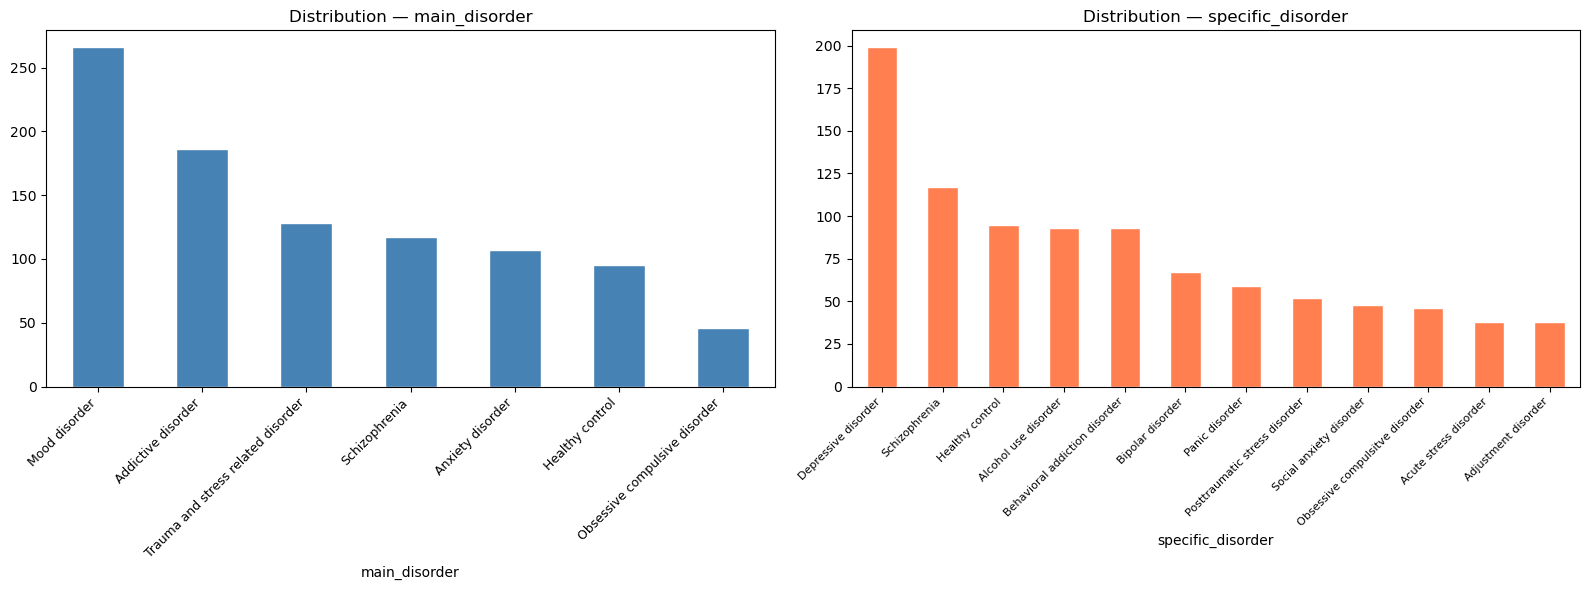

In [3]:
# Distribution des troubles
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df['main_disorder'].value_counts().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Distribution — main_disorder')
axes[0].set_xticklabels(
    df['main_disorder'].value_counts().index,
    rotation=45, ha='right', fontsize=9
)

df['specific_disorder'].value_counts().plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='white'
)
axes[1].set_title('Distribution — specific_disorder')
axes[1].set_xticklabels(
    df['specific_disorder'].value_counts().index,
    rotation=45, ha='right', fontsize=8
)

plt.tight_layout()
plt.savefig('distribution_disorders.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Aplatissement des features EEG

In [4]:
def flatten_features(series, prefix):
    """Transforme une colonne de listes de tuples en DataFrame de colonnes numériques."""
    rows = [{f"{prefix}_{name}": value for name, value in tuples} for tuples in series]
    return pd.DataFrame(rows)

print('Aplatissement ab_features (114 features PSD)')
df_ab = flatten_features(df['ab_features'], 'AB')

print('Aplatissement coh_features (1026 features cohérence)')
df_coh = flatten_features(df['coh_features'], 'COH')

df_demo = df[['age', 'iq', 'education', 'sex']].copy()
X_raw = pd.concat([df_demo, df_ab, df_coh], axis=1)

print(f'\nDataset : {X_raw.shape[0]} patients × {X_raw.shape[1]} features')
print(f'Valeurs nulles : {X_raw.isnull().sum().sum()}')

Aplatissement ab_features (114 features PSD)...
Aplatissement coh_features (1026 features cohérence)...

Dataset : 945 patients × 1144 features
Valeurs nulles : 0


## 4. Normalisation & PCA

Variance expliquée avec 50 composantes : 89.3%


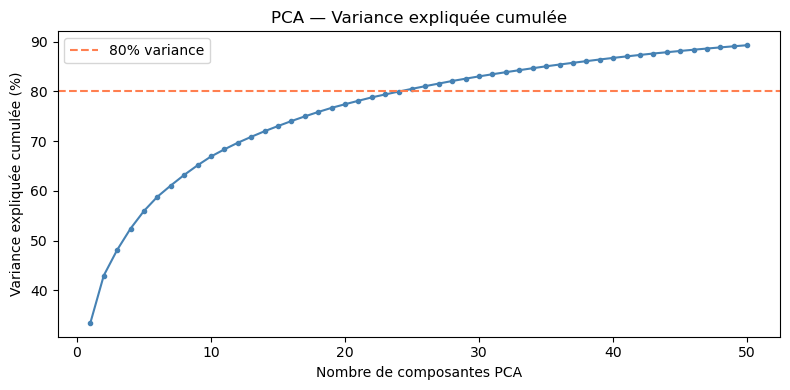

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled)

variance_cumulee = np.cumsum(pca.explained_variance_ratio_)
print(f'Variance expliquée avec 50 composantes : {variance_cumulee[-1]*100:.1f}%')

plt.figure(figsize=(8, 4))
plt.plot(range(1, 51), variance_cumulee * 100, marker='o', markersize=3, color='steelblue')
plt.axhline(y=80, color='coral', linestyle='--', label='80% variance')
plt.xlabel('Nombre de composantes PCA')
plt.ylabel('Variance expliquée cumulée (%)')
plt.title('PCA — Variance expliquée cumulée')
plt.legend()
plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Modèle 1 — SVM Binaire (malade vs sain)
**Entrée** : tous les 945 patients  
**Question** : *"Ce patient est-il atteint d'un trouble psychiatrique ?"*

In [6]:
# Cible binaire : 1 = malade, 0 = sain
y_bin = (df['main_disorder'] != 'Healthy control').astype(int)

print('Distribution :')
print(f'  Malades (1) : {y_bin.sum()} patients ({y_bin.mean()*100:.1f}%)')
print(f'  Sains   (0) : {(y_bin==0).sum()} patients ({(1-y_bin.mean())*100:.1f}%)')

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_pca, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)
print(f'\nTrain : {X_train_b.shape[0]} | Test : {X_test_b.shape[0]}')

Distribution :
  Malades (1) : 850 patients (89.9%)
  Sains   (0) : 95 patients (10.1%)

Train : 756 | Test : 189


In [7]:
print('Entraînement Modèle 1 — SVM...')
svm = SVC(
    kernel='rbf', C=10, gamma='scale',
    class_weight='balanced', random_state=42, probability=True
)
svm.fit(X_train_b, y_train_b)

y_pred_bin = svm.predict(X_test_b)
acc_bin = accuracy_score(y_test_b, y_pred_bin) * 100
f1_bin  = f1_score(y_test_b, y_pred_bin, average='weighted') * 100

print(f'\n✅ Accuracy : {acc_bin:.2f}%')
print(f'✅ F1-score : {f1_bin:.2f}%')
print()
print(classification_report(y_test_b, y_pred_bin, target_names=['Sain', 'Malade']))

Entraînement Modèle 1 — SVM...

✅ Accuracy : 89.95%
✅ F1-score : 87.52%

              precision    recall  f1-score   support

        Sain       0.50      0.16      0.24        19
      Malade       0.91      0.98      0.95       170

    accuracy                           0.90       189
   macro avg       0.71      0.57      0.59       189
weighted avg       0.87      0.90      0.88       189



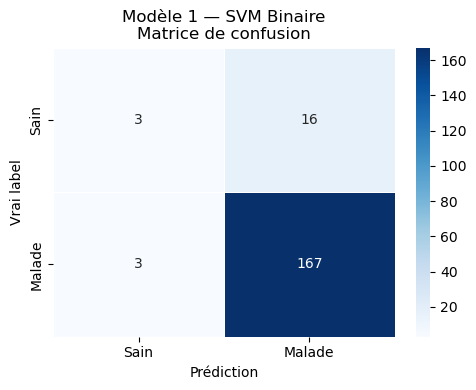

In [8]:
# Matrice de confusion — Modèle 1
cm_bin = confusion_matrix(y_test_b, y_pred_bin)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sain', 'Malade'],
            yticklabels=['Sain', 'Malade'], linewidths=0.5)
plt.title('Modèle 1 — SVM Binaire\nMatrice de confusion')
plt.ylabel('Vrai label')
plt.xlabel('Prédiction')
plt.tight_layout()
plt.savefig('confusion_modele1.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Modèle 2 — XGBoost Multiclasse (quel trouble ?)
**Entrée** : uniquement les patients détectés malades par le Modèle 1  
**Question** : *"Quel type de trouble psychiatrique ce patient présente-t-il ?"*

In [9]:
# Filtrer uniquement les malades (main_disorder != Healthy control)
mask_malades = df['main_disorder'] != 'Healthy control'
df_malades   = df[mask_malades].reset_index(drop=True)
X_pca_malades = X_pca[mask_malades.values]

print(f'Patients malades : {df_malades.shape[0]}')
print()
print('Distribution des troubles :')
print(df_malades['main_disorder'].value_counts())

# Encodage de la cible multiclasse
le = LabelEncoder()
y_multi = le.fit_transform(df_malades['main_disorder'])
print(f'\nClasses : {list(le.classes_)}')

Patients malades : 850

Distribution des troubles :
main_disorder
Mood disorder                         266
Addictive disorder                    186
Trauma and stress related disorder    128
Schizophrenia                         117
Anxiety disorder                      107
Obsessive compulsive disorder          46
Name: count, dtype: int64

Classes : ['Addictive disorder', 'Anxiety disorder', 'Mood disorder', 'Obsessive compulsive disorder', 'Schizophrenia', 'Trauma and stress related disorder']


In [10]:
# Sélection des meilleures features (réduit le bruit)
selector = SelectKBest(f_classif, k=30)
X_selected = selector.fit_transform(X_pca_malades, y_multi)
print(f'Features sélectionnées : {X_selected.shape[1]} / {X_pca_malades.shape[1]}')

# Split train/test
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_selected, y_multi, test_size=0.2, random_state=42, stratify=y_multi
)
print(f'Train : {X_train_m.shape[0]} | Test : {X_test_m.shape[0]}')

Features sélectionnées : 30 / 50
Train : 680 | Test : 170


In [11]:
print('Entraînement Modèle 2 — XGBoost...')
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
    verbosity=0
)
xgb.fit(X_train_m, y_train_m)

y_pred_multi = xgb.predict(X_test_m)
acc_multi = accuracy_score(y_test_m, y_pred_multi) * 100
f1_multi  = f1_score(y_test_m, y_pred_multi, average='macro') * 100

print(f'\n✅ Accuracy   : {acc_multi:.2f}%')
print(f'✅ F1-score macro : {f1_multi:.2f}%')
print()
print(classification_report(y_test_m, y_pred_multi, target_names=le.classes_))

Entraînement Modèle 2 — XGBoost...

✅ Accuracy   : 28.82%
✅ F1-score macro : 20.24%

                                    precision    recall  f1-score   support

                Addictive disorder       0.28      0.35      0.31        37
                  Anxiety disorder       0.10      0.05      0.06        21
                     Mood disorder       0.34      0.47      0.40        53
     Obsessive compulsive disorder       0.00      0.00      0.00         9
                     Schizophrenia       0.25      0.17      0.20        24
Trauma and stress related disorder       0.25      0.23      0.24        26

                          accuracy                           0.29       170
                         macro avg       0.20      0.21      0.20       170
                      weighted avg       0.25      0.29      0.26       170



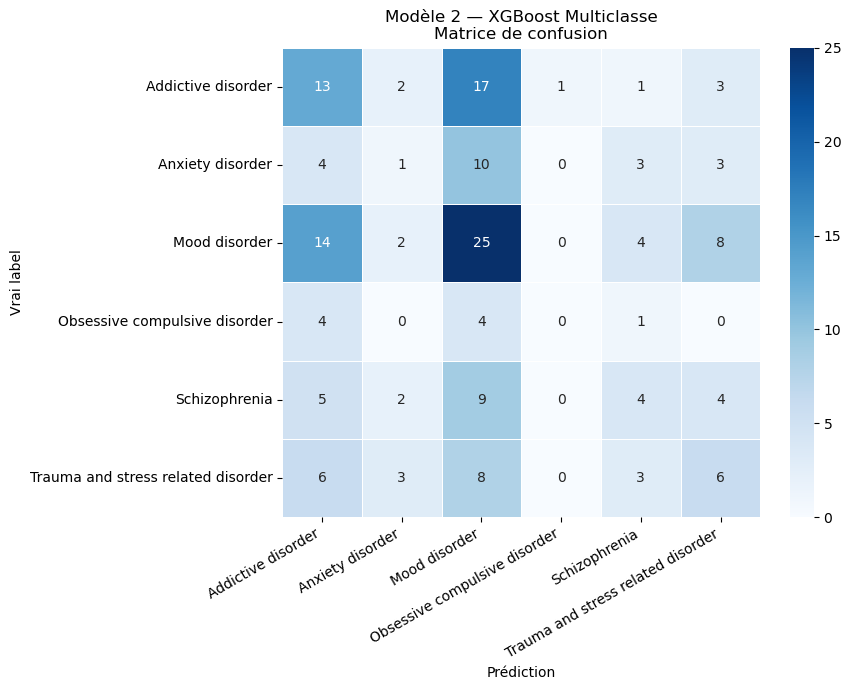

In [12]:
# Matrice de confusion — Modèle 2
cm_multi = confusion_matrix(y_test_m, y_pred_multi)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, linewidths=0.5)
plt.title('Modèle 2 — XGBoost Multiclasse\nMatrice de confusion')
plt.ylabel('Vrai label')
plt.xlabel('Prédiction')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_modele2.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Pipeline complet — Prédiction hiérarchique

In [13]:
# Appliquer le pipeline complet sur tous les 945 patients

# Étape 1 — Modèle 1 : malade ou sain ?
y_bin_all   = svm.predict(X_pca)
proba_bin   = svm.predict_proba(X_pca).max(axis=1).round(4)

# Étape 2 — Modèle 2 : quel trouble ? (uniquement sur les malades détectés)
mask_pred_malades = y_bin_all == 1
X_malades_pred    = selector.transform(X_pca[mask_pred_malades])
y_disorder_pred   = xgb.predict(X_malades_pred)
proba_multi_pred  = xgb.predict_proba(X_malades_pred).max(axis=1).round(4)

# Assemblage des résultats
predicted_disorder = np.array(['Healthy control'] * len(df), dtype=object)
confidence_multi   = np.zeros(len(df))

predicted_disorder[mask_pred_malades] = le.inverse_transform(y_disorder_pred)
confidence_multi[mask_pred_malades]   = proba_multi_pred

print(f'Patients détectés malades  : {mask_pred_malades.sum()}')
print(f'Patients détectés sains    : {(~mask_pred_malades).sum()}')
print()
print('Distribution des troubles prédits :')
print(pd.Series(predicted_disorder).value_counts())

Patients détectés malades  : 859
Patients détectés sains    : 86

Distribution des troubles prédits :
Mood disorder                         293
Addictive disorder                    195
Trauma and stress related disorder    129
Schizophrenia                         110
Anxiety disorder                       95
Healthy control                        86
Obsessive compulsive disorder          37
Name: count, dtype: int64


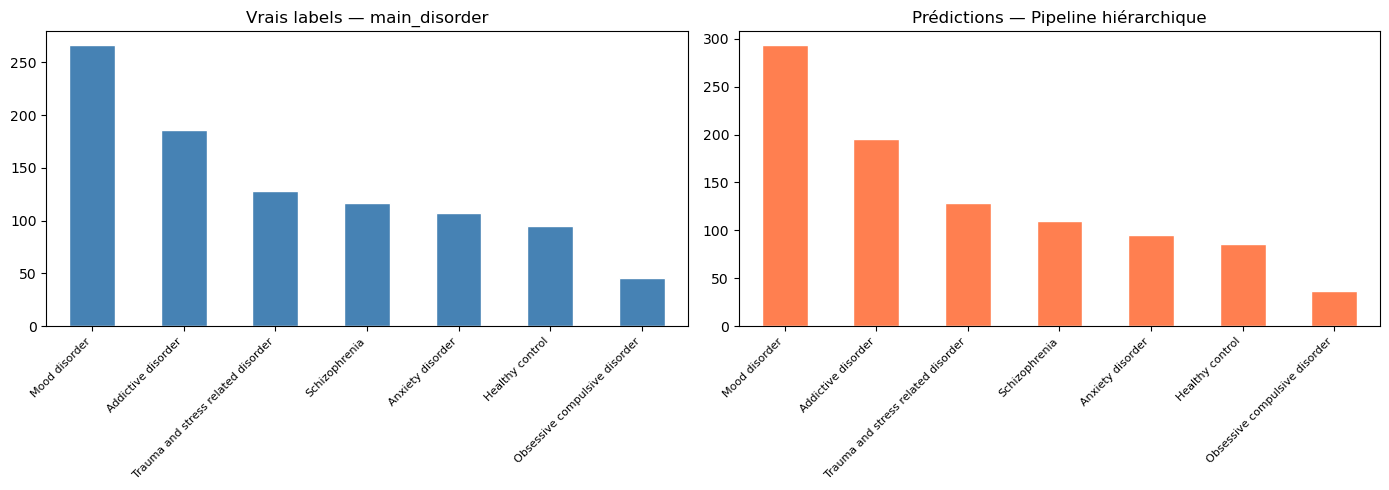

In [14]:
# Visualisation pipeline complet
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Vrais labels vs prédictions
pd.Series(df['main_disorder'].values).value_counts().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Vrais labels — main_disorder')
axes[0].set_xticklabels(
    pd.Series(df['main_disorder'].values).value_counts().index,
    rotation=45, ha='right', fontsize=8
)

pd.Series(predicted_disorder).value_counts().plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='white'
)
axes[1].set_title('Prédictions — Pipeline hiérarchique')
axes[1].set_xticklabels(
    pd.Series(predicted_disorder).value_counts().index,
    rotation=45, ha='right', fontsize=8
)

plt.tight_layout()
plt.savefig('pipeline_resultats.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Résumé des performances

In [15]:
print('=' * 50)
print('RÉSUMÉ — PIPELINE HIÉRARCHIQUE')
print('=' * 50)
print()
print('MODÈLE 1 — SVM Binaire (malade vs sain)')
print(f'  Accuracy  : {acc_bin:.2f}%')
print(f'  F1-score  : {f1_bin:.2f}%')
print(f'  Patients  : 945 (tous)')
print()
print('MODÈLE 2 — XGBoost Multiclasse (quel trouble ?)')
print(f'  Accuracy     : {acc_multi:.2f}%')
print(f'  F1-score macro : {f1_multi:.2f}%')
print(f'  Patients     : {df_malades.shape[0]} (malades uniquement)')

RÉSUMÉ — PIPELINE HIÉRARCHIQUE

MODÈLE 1 — SVM Binaire (malade vs sain)
  Accuracy  : 89.95%
  F1-score  : 87.52%
  Patients  : 945 (tous)

MODÈLE 2 — XGBoost Multiclasse (quel trouble ?)
  Accuracy     : 28.82%
  F1-score macro : 20.24%
  Patients     : 850 (malades uniquement)


## 9. Sauvegarde des modèles

In [16]:
joblib.dump(svm,      'modele1_svm.pkl')
joblib.dump(xgb,      'modele2_xgboost.pkl')
joblib.dump(selector, 'selector.pkl')
joblib.dump(scaler,   'scaler.pkl')
joblib.dump(le,       'label_encoder.pkl')
joblib.dump(pca,      'pca.pkl')

print('Modèles sauvegardés :')
print(' modele1_svm.pkl')
print(' modele2_xgboost.pkl')
print(' selector.pkl')
print(' scaler.pkl')
print(' label_encoder.pkl')
print(' pca.pkl')

Modèles sauvegardés :
 modele1_svm.pkl
 modele2_xgboost.pkl
 selector.pkl
 scaler.pkl
 label_encoder.pkl
 pca.pkl


## 10. Génération du fichier output pour MS2

In [19]:
df_output = df[['id', 'sex', 'age', 'education', 'iq',
                'main_disorder', 'specific_disorder']].copy()

# Résultats Modèle 1
df_output['is_patient_true']   = (df['main_disorder'] != 'Healthy control').astype(int)
df_output['is_patient_pred']   = y_bin_all
df_output['binary_confidence'] = proba_bin

# Résultats Modèle 2
df_output['predicted_disorder'] = predicted_disorder
df_output['multi_confidence']   = confidence_multi

df_output.to_parquet('datasetpredection.parquet', index=False)

print('results.parquet sauvegardé')
print(f'Shape : {df_output.shape}')
display(df_output.head(10))

results.parquet sauvegardé
Shape : (945, 12)


,id,sex,age,education,iq,main_disorder,specific_disorder,is_patient_true,is_patient_pred,binary_confidence,predicted_disorder,multi_confidence
0,1,0,0.723831,0.65,0.552083,Addictive disorder,Alcohol use disorder,1,1,0.9730,Addictive disorder,0.9772
1,2,0,0.352635,0.30,0.739583,Addictive disorder,Alcohol use disorder,1,1,0.9365,Trauma and stress related disorder,0.4288
2,3,0,0.259837,0.80,0.666667,Addictive disorder,Alcohol use disorder,1,1,0.9649,Addictive disorder,0.9865
3,4,0,0.315516,0.90,0.802083,Addictive disorder,Alcohol use disorder,1,1,0.9147,Addictive disorder,0.9841
4,5,0,0.334076,0.80,0.656250,Addictive disorder,Alcohol use disorder,1,1,0.9614,Addictive disorder,0.9799
5,6,1,0.111359,0.70,0.583333,Addictive disorder,Alcohol use disorder,1,1,0.9432,Addictive disorder,0.9864
6,7,1,0.148478,0.80,0.562500,Addictive disorder,Alcohol use disorder,1,1,0.9818,Addictive disorder,0.9785
7,8,0,0.092799,0.60,0.572917,Addictive disorder,Alcohol use disorder,1,1,0.9337,Addictive disorder,0.9854
8,9,0,0.111359,0.85,0.416667,Addictive disorder,Alcohol use disorder,1,1,0.9621,Addictive disorder,0.9841
9,10,1,0.222717,0.60,0.510417,Addictive disorder,Alcohol use disorder,1,1,0.9234,Addictive disorder,0.9804
